In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

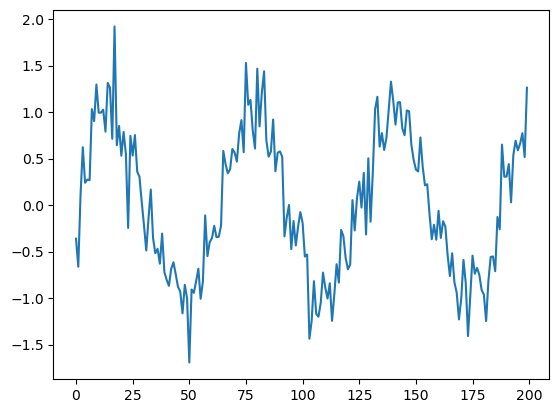

In [3]:
# Generate fake sensor data
n_samples = 200
time = np.linspace(0, 10, n_samples)
data = np.sin(time*2) + np.random.normal(0, 0.3, n_samples)

plt.plot(data)

In [39]:
class TimeSeriesSeq2Seq(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.encoder_rnn = nn.GRU(1, hidden_dim, batch_first=True)
        self.decoder_rnn = nn.GRU(1, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    
    def forward(self, x, horizon):
        # encode
        _, hidden = self.encoder_rnn(x)
        
        # decode
        decoder_input = x[:, -1:, :]  # Start with last input value
        outputs = []
        
        for _ in range(horizon):
            out, hidden = self.decoder_rnn(decoder_input, hidden)
            prediction = self.fc(out)
            outputs.append(prediction)
            decoder_input = prediction  # Use prediction as next input
        
        return torch.cat(outputs, dim=1)

In [40]:
# prepare data: use input_len past values to predict output_len future values
input_len, horizon = 60, 100

X, y = [], []
for i in range(len(data) - input_len - horizon):
    X.append(data[i:i+input_len])
    y.append(data[i+input_len:i+input_len+horizon])

X = np.array(X)
y = np.array(y)

X = torch.FloatTensor(X).unsqueeze(-1)  # Shape: [samples, 10, 1]
y = torch.FloatTensor(y).unsqueeze(-1)  # Shape: [samples, 5, 1]

Train

In [42]:
model = TimeSeriesSeq2Seq()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(100):
    optimizer.zero_grad()
    predictions = model(X, horizon)
    loss = criterion(predictions, y)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.2f}')

# test prediction
test_input = X[0:1]  # take first sequence
prediction = model(test_input, horizon)
print(f'Predicted: {prediction[0, :, 0].detach().numpy()}')
print(f'True Values: {y[0, :, 0].numpy()}')

Epoch 10, Loss: 0.53
Epoch 20, Loss: 0.52
Epoch 30, Loss: 0.52
Epoch 40, Loss: 0.49
Epoch 50, Loss: 0.30
Epoch 60, Loss: 0.16
Epoch 70, Loss: 0.08
Epoch 80, Loss: 0.08
Epoch 90, Loss: 0.07
Epoch 100, Loss: 0.07
Predicted: [-0.16625273 -0.09981085 -0.01759331  0.07256876  0.16647364  0.2615446
  0.35612744  0.4490978   0.539581    0.62671554  0.7094587   0.78647137
  0.85612476  0.91662693  0.9662204   1.0033814   1.0269723   1.0363297
  1.031295    1.0121912   0.97974813  0.9349755   0.8789996   0.8129056
  0.7376423   0.65403825  0.5629614   0.4656009   0.36377633  0.26008457
  0.15765624  0.05946144 -0.0325259  -0.11779752 -0.1971807  -0.2723335
 -0.34521794 -0.41772264 -0.49141508 -0.5673197  -0.64561623 -0.72523046
 -0.80347306 -0.8761245  -0.93833405 -0.98608935 -1.0173349  -1.0320519
 -1.0315492  -1.0176513  -0.99217415 -0.956702   -0.9125438  -0.8607664
 -0.80224794 -0.73773205 -0.6678874  -0.5933738  -0.51490724 -0.43329132
 -0.3493865  -0.26402283 -0.17790285 -0.0915511  -0.00

In [43]:
prediction.shape, y.shape

(torch.Size([1, 100, 1]), torch.Size([40, 100, 1]))

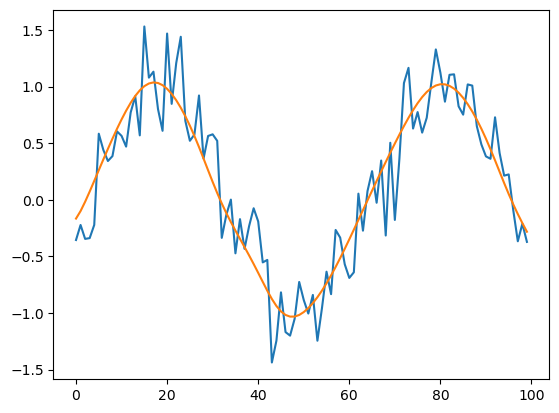

In [44]:
import matplotlib.pyplot as plt

with torch.no_grad():
    plt.plot(y[0,:])
    plt.plot(prediction[0,:])